 # Diagnostic: Matched Filter vs Threshold Detection
 This notebook compares matched filtering detection with simple thresholding

In [46]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
# %matplotlib qt
# %matplotlib widget

from pathlib import Path
from scipy.signal import correlate

import spikeinterface as si
import spikeinterface.preprocessing as spre
import spikeinterface.extractors as se
from spikeinterface.sortingcomponents.peak_detection import detect_peaks

# Add parent dir to path so we can import RCP_analysis
REPO_ROOT = Path(os.getcwd()).resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import RCP_analysis as rcp
from RCP_analysis.python.functions.config_loading import *

print(f"REPO_ROOT: {REPO_ROOT}")
print(f"BR_ROOT: {BR_ROOT}")
print(f"UA_CKPT_ROOT: {UA_CKPT_ROOT}")

REPO_ROOT: E:\NHP_Cerebellum_Project_2025_RCP_Analysis_Git\RCP_analysis
BR_ROOT: \\cullenstor.win.ad.jhu.edu\data\Current Project Databases - NHP\2025 Cerebellum prosthesis\Nike\20260311_NRR_RW022\Blackrock
UA_CKPT_ROOT: \\cullenstor.win.ad.jhu.edu\data\Current Project Databases - NHP\2025 Cerebellum prosthesis\Nike\20260311_NRR_RW022\results\checkpoints\UA


In [47]:
SESSION_NAME = "NRR_RW022_001"
DEBUG_ELECTRODE = 24
TIME_WINDOW_MS = (5000, 10000)
THRESH_SIMPLE = 4.0
THRESH_MF = 3.5
PEAK_SIGN = "neg"
HIGHPASS_HZ = 300.0

# Paths
PREPROCESSED_PATH = UA_CKPT_ROOT / f"pp__{SESSION_NAME}__NS6"
TEMPLATE_PATH = REPO_ROOT / "config" / "median_extremum_templates_norm_UA_PortB.npy"

print(f"Preprocessed path: {PREPROCESSED_PATH}")
print(f"  Exists: {PREPROCESSED_PATH.exists()}")
print(f"Template path: {TEMPLATE_PATH}")
print(f"  Exists: {TEMPLATE_PATH.exists()}")

Preprocessed path: \\cullenstor.win.ad.jhu.edu\data\Current Project Databases - NHP\2025 Cerebellum prosthesis\Nike\20260311_NRR_RW022\results\checkpoints\UA\pp__NRR_RW022_001__NS6
  Exists: True
Template path: E:\NHP_Cerebellum_Project_2025_RCP_Analysis_Git\RCP_analysis\config\median_extremum_templates_norm_UA_PortB.npy
  Exists: True


In [48]:
print(f"Loading session: {SESSION_NAME}")

if PREPROCESSED_PATH.exists():
    print(f"Loading preprocessed recording from: {PREPROCESSED_PATH}")
    rec = si.load(PREPROCESSED_PATH)
else:
    print("Preprocessed not found. Loading raw and preprocessing on the fly...")
    sess_path = BR_ROOT / SESSION_NAME
    if not sess_path.exists():
        raise FileNotFoundError(f"Raw session path not found: {sess_path}")
    
    rec_raw = se.read_blackrock(sess_path, stream_name='nsx6', all_annotations=True)
    
    # Apply channel mapping
    XLS = rcp.ua_excel_path(REPO_ROOT, PARAMS.probes)
    UA_MAP = rcp.load_UA_mapping_from_excel(XLS)
    br_idx = int(SESSION_NAME.split('_')[-1])
    
    rec_raw, idx_rows, ua_elec, ua_nsp, ua_region, ua_region_names, ua_port = \
        rcp.apply_ua_mapping_with_regions(rec_raw, UA_MAP, br_idx, METADATA_CSV)
    
    # Highpass filter
    rec = spre.highpass_filter(rec_raw, freq_min=HIGHPASS_HZ)

fs = rec.get_sampling_frequency()
print(f"Sampling frequency: {fs} Hz")
print(f"Recording duration: {rec.get_total_duration():.1f} s")
print(f"Number of channels: {rec.get_num_channels()}")

Loading session: NRR_RW022_001
Loading preprocessed recording from: \\cullenstor.win.ad.jhu.edu\data\Current Project Databases - NHP\2025 Cerebellum prosthesis\Nike\20260311_NRR_RW022\results\checkpoints\UA\pp__NRR_RW022_001__NS6
Sampling frequency: 30000.0 Hz
Recording duration: 106.0 s
Number of channels: 128



Loading template from: E:\NHP_Cerebellum_Project_2025_RCP_Analysis_Git\RCP_analysis\config\median_extremum_templates_norm_UA_PortB.npy
Template shape: (105,)
Template length: 105 samples = 3.50 ms
Peak at sample 45 (1.500 ms from start)


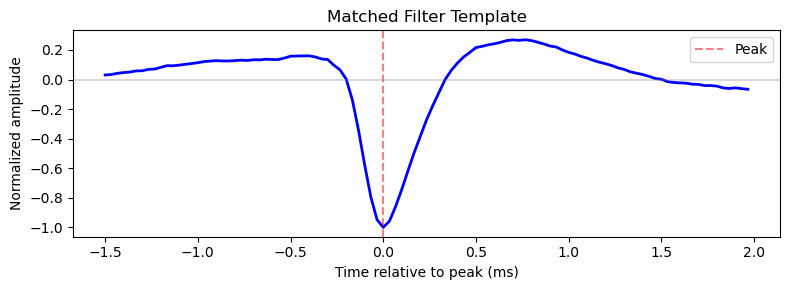

In [49]:
print(f"\nLoading template from: {TEMPLATE_PATH}")
template = np.load(TEMPLATE_PATH)
print(f"Template shape: {template.shape}")
print(f"Template length: {len(template)} samples = {len(template)/fs*1000:.2f} ms")

nbefore = np.argmin(template)
ms_before = nbefore / fs * 1000
print(f"Peak at sample {nbefore} ({ms_before:.3f} ms from start)")

# Plot template
fig, ax = plt.subplots(figsize=(8, 3))
t_template = (np.arange(len(template)) - nbefore) / fs * 1000
ax.plot(t_template, template, 'b-', lw=2)
ax.axvline(0, color='r', linestyle='--', alpha=0.5, label='Peak')
ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Time relative to peak (ms)')
ax.set_ylabel('Normalized amplitude')
ax.set_title('Matched Filter Template')
ax.legend()
plt.tight_layout()
plt.show()

In [50]:
ch_ids = rec.get_channel_ids()

# Try to find the electrode in channel properties
debug_ch_idx = None
try:
    ua_elec_prop = rec.get_property('ua_elec')
    if ua_elec_prop is not None:
        for i, elec in enumerate(ua_elec_prop):
            if int(elec) == DEBUG_ELECTRODE:
                debug_ch_idx = i
                break
except:
    pass

if debug_ch_idx is None:
    # Fallback: use as index
    debug_ch_idx = min(DEBUG_ELECTRODE, len(ch_ids) - 1)
    print(f"Using channel index {debug_ch_idx} as fallback")

debug_ch_id = ch_ids[debug_ch_idx]
print(f"Debug channel: index={debug_ch_idx}, id={debug_ch_id}")

Using channel index 24 as fallback
Debug channel: index=24, id=UAe033_NSP153


In [51]:
t0_ms, t1_ms = TIME_WINDOW_MS
t0_samp = int(t0_ms * fs / 1000)
t1_samp = int(t1_ms * fs / 1000)

n_samples = rec.get_num_samples()
t0_samp = max(0, t0_samp)
t1_samp = min(n_samples, t1_samp)

print(f"Extracting window: {t0_ms:.1f} - {t1_ms:.1f} ms")
print(f"Sample range: {t0_samp} - {t1_samp}")

trace = rec.get_traces(
    start_frame=t0_samp,
    end_frame=t1_samp,
    channel_ids=[debug_ch_id],
    return_scaled=True
).flatten()

t_ms = np.arange(len(trace)) / fs * 1000 + t0_ms
print(f"Trace stats: min={trace.min():.1f}, max={trace.max():.1f}, std={trace.std():.1f} µV")

Extracting window: 5000.0 - 10000.0 ms
Sample range: 150000 - 300000
Trace stats: min=-83.2, max=115.8, std=5.6 µV


C:\Users\culle\AppData\Local\Temp\ipykernel_36060\2270535453.py:12: DeprecationWarning: `return_scaled` is deprecated and will be removed in version 0.105.0. Use `return_in_uV` instead.
  trace = rec.get_traces(


In [52]:
noise_level = np.median(np.abs(trace - np.median(trace))) / 0.6745
thresh_uV = THRESH_SIMPLE * noise_level
print(f"Noise level (MAD): {noise_level:.2f} µV")
print(f"Simple threshold ({THRESH_SIMPLE}σ): {thresh_uV:.1f} µV")

# MF output
template_energy = np.sqrt(np.sum(template**2))
mf_output = correlate(trace, template, mode='same')
mf_output_norm = mf_output / template_energy

mf_noise = np.median(np.abs(mf_output_norm - np.median(mf_output_norm))) / 0.6745
mf_thresh = THRESH_MF * mf_noise
print(f"MF noise level: {mf_noise:.2f}")
print(f"MF threshold ({THRESH_MF}σ): {mf_thresh:.1f}")

Noise level (MAD): 5.56 µV
Simple threshold (4.0σ): 22.2 µV
MF noise level: 15.32
MF threshold (3.5σ): 53.6


In [53]:
print("\nRunning simple threshold detection...")

below_thresh = trace < -thresh_uV
crossings = np.where(np.diff(below_thresh.astype(int)) == 1)[0]

simple_peak_idx = []
simple_peak_amp = []
for c in crossings:
    win_start = max(0, c - int(0.5 * fs / 1000))
    win_end = min(len(trace), c + int(1.5 * fs / 1000))
    local_min_idx = win_start + np.argmin(trace[win_start:win_end])
    if trace[local_min_idx] < -thresh_uV:
        simple_peak_idx.append(local_min_idx)
        simple_peak_amp.append(trace[local_min_idx])

simple_peak_idx = np.array(simple_peak_idx)
simple_peak_amp = np.array(simple_peak_amp)

# Remove duplicates
if len(simple_peak_idx) > 1:
    min_sep = int(0.5 * fs / 1000)
    keep = [0]
    for i in range(1, len(simple_peak_idx)):
        if simple_peak_idx[i] - simple_peak_idx[keep[-1]] >= min_sep:
            keep.append(i)
    simple_peak_idx = simple_peak_idx[keep]
    simple_peak_amp = simple_peak_amp[keep]

print(f"Simple threshold found {len(simple_peak_idx)} peaks")


Running simple threshold detection...
Simple threshold found 28 peaks


In [54]:
print("\nRunning matched filter detection...")

mf_below = mf_output_norm < -mf_thresh
mf_crossings = np.where(np.diff(mf_below.astype(int)) == 1)[0]

mf_peak_idx = []
mf_peak_amp = []
for c in mf_crossings:
    win_start = max(0, c - int(0.5 * fs / 1000))
    win_end = min(len(mf_output_norm), c + int(1.5 * fs / 1000))
    local_idx = win_start + np.argmin(mf_output_norm[win_start:win_end])
    mf_peak_idx.append(local_idx)
    mf_peak_amp.append(mf_output_norm[local_idx])

mf_peak_idx = np.array(mf_peak_idx)
mf_peak_amp = np.array(mf_peak_amp)

if len(mf_peak_idx) > 1:
    min_sep = int(0.5 * fs / 1000)
    keep = [0]
    for i in range(1, len(mf_peak_idx)):
        if mf_peak_idx[i] - mf_peak_idx[keep[-1]] >= min_sep:
            keep.append(i)
    mf_peak_idx = mf_peak_idx[keep]
    mf_peak_amp = mf_peak_amp[keep]

print(f"Matched filter found {len(mf_peak_idx)} peaks")


Running matched filter detection...
Matched filter found 13 peaks


In [55]:
tolerance_samp = int(0.5 * fs / 1000)
matched_simple = []
matched_mf = []

for s in simple_peak_idx:
    for m in mf_peak_idx:
        if abs(s - m) <= tolerance_samp:
            matched_simple.append(s)
            matched_mf.append(m)
            break

simple_only = [s for s in simple_peak_idx if s not in matched_simple]
mf_only = [m for m in mf_peak_idx if m not in matched_mf]
both = matched_simple

print(f"\nComparison:")
print(f"  Simple only: {len(simple_only)}")
print(f"  MF only: {len(mf_only)}")
print(f"  Both: {len(both)}")


Comparison:
  Simple only: 28
  MF only: 13
  Both: 0


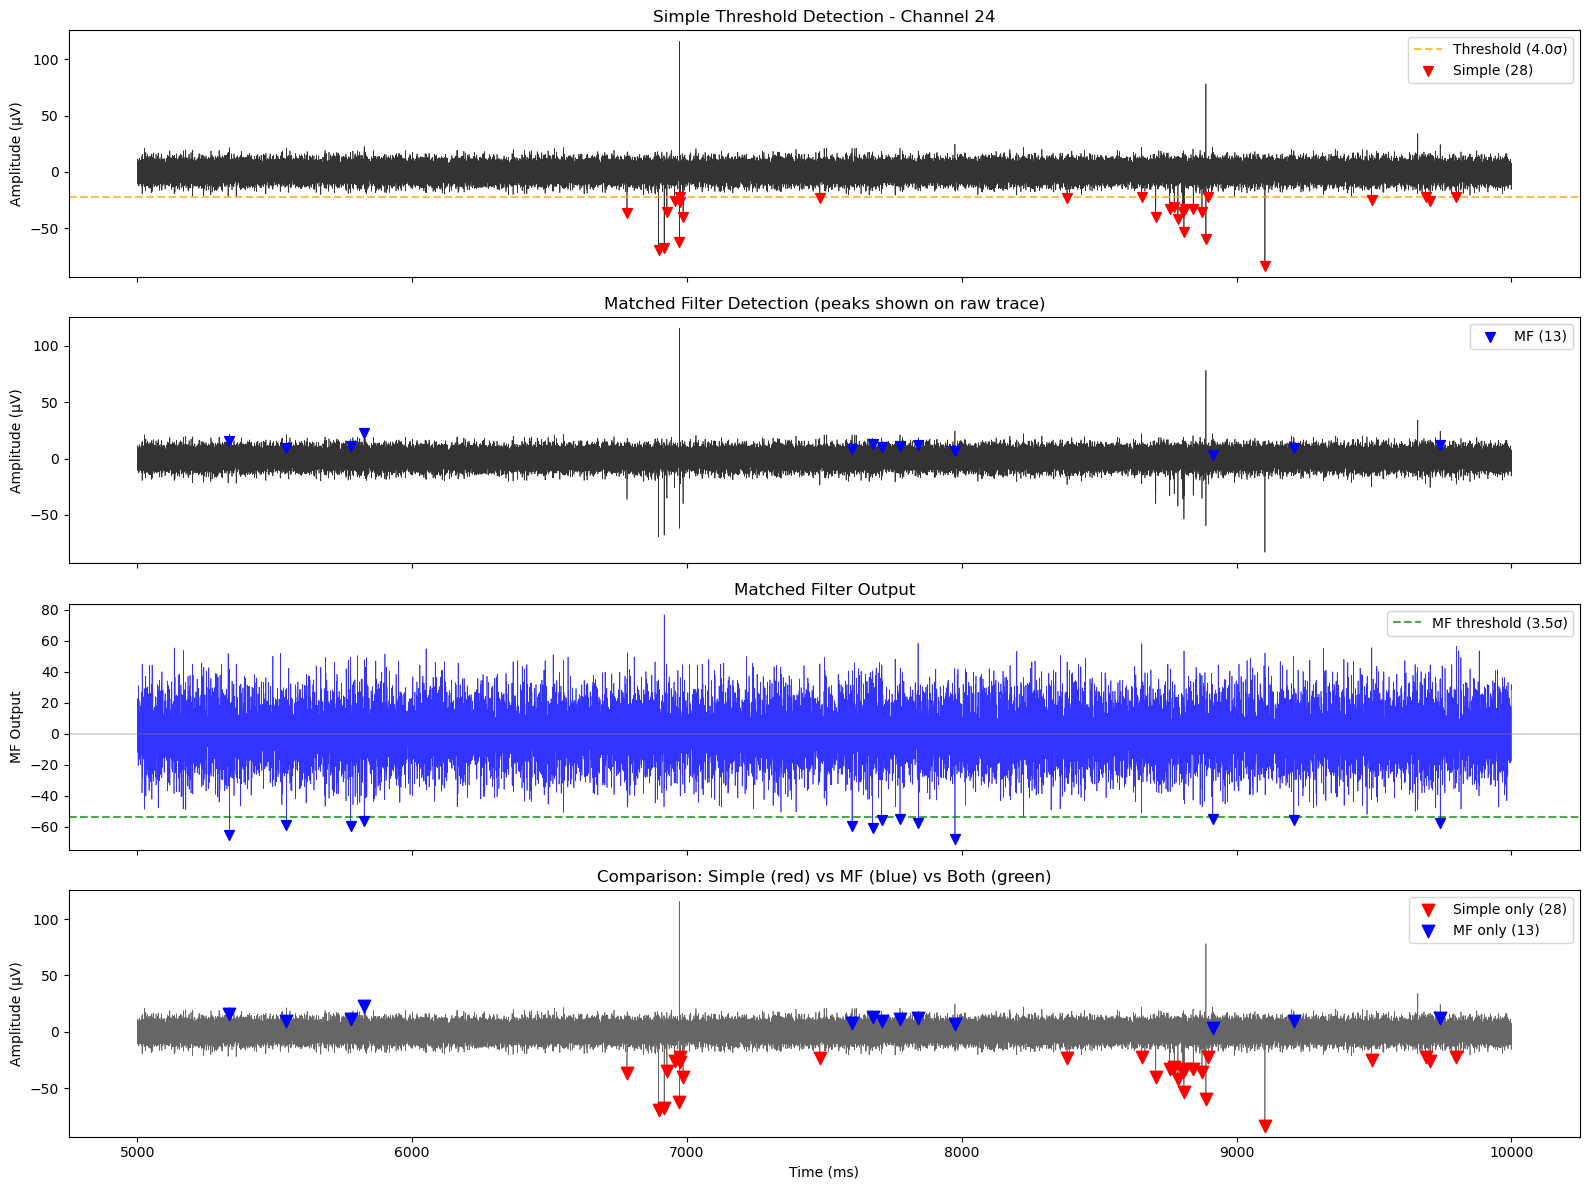

In [56]:
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

# Panel 1: Simple threshold
ax = axes[0]
ax.plot(t_ms, trace, 'k-', lw=0.5, alpha=0.8)
ax.axhline(-thresh_uV, color='orange', linestyle='--', alpha=0.7, label=f'Threshold ({THRESH_SIMPLE}σ)')
if len(simple_peak_idx) > 0:
    ax.scatter(t_ms[simple_peak_idx], simple_peak_amp, c='red', s=50, marker='v', zorder=5, 
               label=f'Simple ({len(simple_peak_idx)})')
ax.set_ylabel('Amplitude (µV)')
ax.set_title(f'Simple Threshold Detection - Channel {debug_ch_idx}')
ax.legend(loc='upper right')

# Panel 2: Matched filter (on raw trace)
ax = axes[1]
ax.plot(t_ms, trace, 'k-', lw=0.5, alpha=0.8)
if len(mf_peak_idx) > 0:
    ax.scatter(t_ms[mf_peak_idx], trace[mf_peak_idx], c='blue', s=50, marker='v', zorder=5,
               label=f'MF ({len(mf_peak_idx)})')
ax.set_ylabel('Amplitude (µV)')
ax.set_title('Matched Filter Detection (peaks shown on raw trace)')
ax.legend(loc='upper right')

# Panel 3: MF output
ax = axes[2]
ax.plot(t_ms, mf_output_norm, 'b-', lw=0.5, alpha=0.8)
ax.axhline(-mf_thresh, color='green', linestyle='--', alpha=0.7, label=f'MF threshold ({THRESH_MF}σ)')
ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
if len(mf_peak_idx) > 0:
    ax.scatter(t_ms[mf_peak_idx], mf_peak_amp, c='blue', s=50, marker='v', zorder=5)
ax.set_ylabel('MF Output')
ax.set_title('Matched Filter Output')
ax.legend(loc='upper right')

# Panel 4: Comparison
ax = axes[3]
ax.plot(t_ms, trace, 'k-', lw=0.5, alpha=0.6)
if len(simple_only) > 0:
    ax.scatter(t_ms[simple_only], trace[simple_only], c='red', s=80, marker='v', zorder=5,
               label=f'Simple only ({len(simple_only)})')
if len(mf_only) > 0:
    ax.scatter(t_ms[mf_only], trace[mf_only], c='blue', s=80, marker='v', zorder=5,
               label=f'MF only ({len(mf_only)})')
if len(both) > 0:
    ax.scatter(t_ms[both], trace[both], c='green', s=80, marker='v', zorder=5,
               label=f'Both ({len(both)})')
ax.set_ylabel('Amplitude (µV)')
ax.set_xlabel('Time (ms)')
ax.set_title('Comparison: Simple (red) vs MF (blue) vs Both (green)')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('detection_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [57]:
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"Simple threshold: {len(simple_peak_idx)} detections")
print(f"Matched filter:   {len(mf_peak_idx)} detections")
print(f"Agreement:        {len(both)} peaks detected by both")
print(f"Simple only:      {len(simple_only)}")
print(f"MF only:          {len(mf_only)}")


SUMMARY
Simple threshold: 28 detections
Matched filter:   13 detections
Agreement:        0 peaks detected by both
Simple only:      28
MF only:          13


In [58]:
# %% Cell 13: Waveform Extraction and Comparison

print("\n=== Extracting waveforms around detected peaks ===")

# Parameters for waveform extraction
wf_ms_before = 1.0
wf_ms_after = 2.0
wf_samp_before = int(wf_ms_before * fs / 1000)
wf_samp_after = int(wf_ms_after * fs / 1000)
wf_len = wf_samp_before + wf_samp_after

def extract_waveforms(trace, peak_indices, n_before, n_after):
    """Extract waveforms around peak indices."""
    waveforms = []
    valid_indices = []
    for idx in peak_indices:
        start = idx - n_before
        end = idx + n_after
        if start >= 0 and end <= len(trace):
            waveforms.append(trace[start:end])
            valid_indices.append(idx)
    if len(waveforms) == 0:
        return np.array([]).reshape(0, n_before + n_after), np.array([])
    return np.array(waveforms), np.array(valid_indices)

# Extract waveforms for each category
wf_simple_only, idx_simple_valid = extract_waveforms(trace, simple_only, wf_samp_before, wf_samp_after)
wf_mf_only, idx_mf_valid = extract_waveforms(trace, mf_only, wf_samp_before, wf_samp_after)
wf_both, idx_both_valid = extract_waveforms(trace, both, wf_samp_before, wf_samp_after)

# Also extract ALL simple and ALL MF detections for comparison
wf_all_simple, _ = extract_waveforms(trace, simple_peak_idx, wf_samp_before, wf_samp_after)
wf_all_mf, _ = extract_waveforms(trace, mf_peak_idx, wf_samp_before, wf_samp_after)

t_wf = (np.arange(wf_len) - wf_samp_before) / fs * 1000

print(f"Extracted waveforms:")
print(f"  Simple only: {len(wf_simple_only)}")
print(f"  MF only: {len(wf_mf_only)}")
print(f"  Both: {len(wf_both)}")
print(f"  All Simple: {len(wf_all_simple)}")
print(f"  All MF: {len(wf_all_mf)}")


=== Extracting waveforms around detected peaks ===
Extracted waveforms:
  Simple only: 28
  MF only: 13
  Both: 0
  All Simple: 28
  All MF: 13


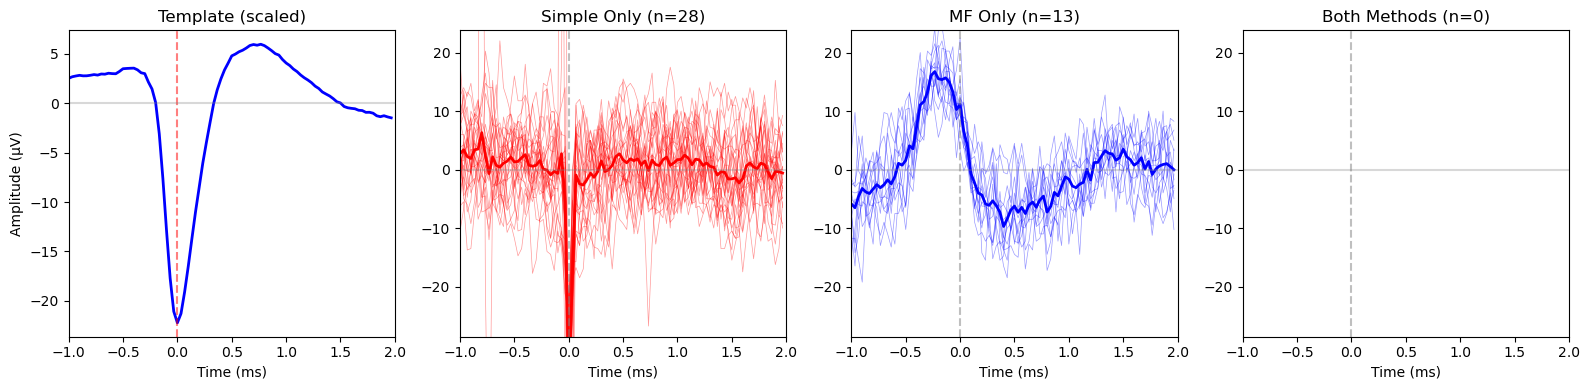

In [59]:
# %% Cell 14: Plot Waveforms by Category

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Scale template to typical amplitude for comparison
template_scaled = template * thresh_uV / abs(template.min())
t_template_plot = (np.arange(len(template)) - nbefore) / fs * 1000

# Panel 1: Template
ax = axes[0]
ax.plot(t_template_plot, template_scaled, 'b-', lw=2)
ax.axvline(0, color='r', linestyle='--', alpha=0.5)
ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Amplitude (µV)')
ax.set_title('Template (scaled)')
ax.set_xlim(-wf_ms_before, wf_ms_after)

# Panel 2: Simple Only
ax = axes[1]
if len(wf_simple_only) > 0:
    for wf in wf_simple_only:
        ax.plot(t_wf, wf, 'r-', lw=0.5, alpha=0.4)
    ax.plot(t_wf, np.mean(wf_simple_only, axis=0), 'r-', lw=2, label='Mean')
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Time (ms)')
ax.set_title(f'Simple Only (n={len(wf_simple_only)})')
ax.set_xlim(-wf_ms_before, wf_ms_after)

# Panel 3: MF Only
ax = axes[2]
if len(wf_mf_only) > 0:
    for wf in wf_mf_only:
        ax.plot(t_wf, wf, 'b-', lw=0.5, alpha=0.4)
    ax.plot(t_wf, np.mean(wf_mf_only, axis=0), 'b-', lw=2, label='Mean')
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Time (ms)')
ax.set_title(f'MF Only (n={len(wf_mf_only)})')
ax.set_xlim(-wf_ms_before, wf_ms_after)

# Panel 4: Both
ax = axes[3]
if len(wf_both) > 0:
    for wf in wf_both:
        ax.plot(t_wf, wf, 'g-', lw=0.5, alpha=0.4)
    ax.plot(t_wf, np.mean(wf_both, axis=0), 'g-', lw=2, label='Mean')
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Time (ms)')
ax.set_title(f'Both Methods (n={len(wf_both)})')
ax.set_xlim(-wf_ms_before, wf_ms_after)

# Sync y-axes across waveform panels
all_wfs = []
for wfs in [wf_simple_only, wf_mf_only, wf_both]:
    if len(wfs) > 0:
        all_wfs.extend(wfs.flatten())
if all_wfs:
    ymin, ymax = np.percentile(all_wfs, [1, 99])
    yrange = ymax - ymin
    for ax in axes[1:]:
        ax.set_ylim(ymin - 0.15*yrange, ymax + 0.15*yrange)

plt.tight_layout()
plt.savefig('waveform_comparison_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

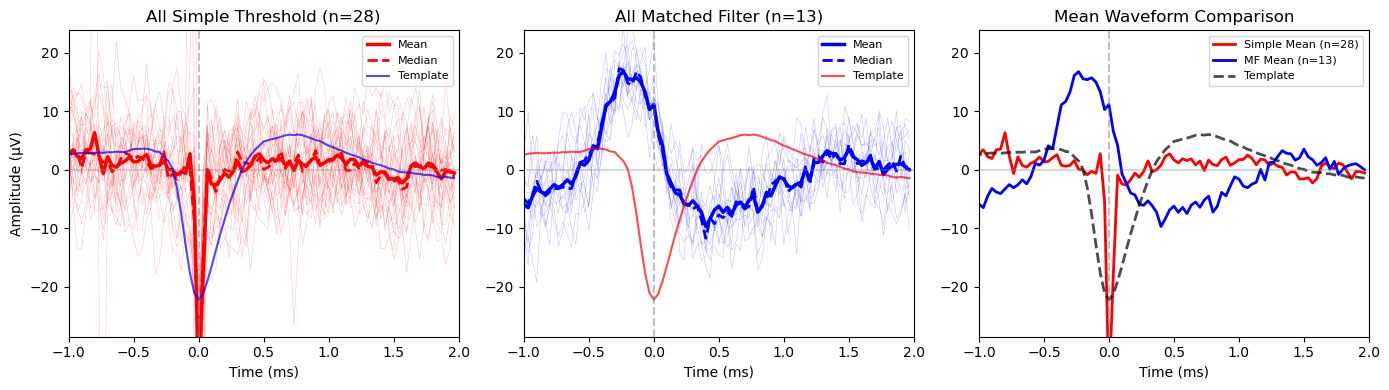

In [60]:
# %% Cell 15: All Simple vs All MF Waveforms

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel 1: All Simple Threshold Detections
ax = axes[0]
if len(wf_all_simple) > 0:
    for wf in wf_all_simple:
        ax.plot(t_wf, wf, 'r-', lw=0.3, alpha=0.3)
    ax.plot(t_wf, np.mean(wf_all_simple, axis=0), 'r-', lw=2.5, label='Mean')
    ax.plot(t_wf, np.median(wf_all_simple, axis=0), 'r--', lw=2, label='Median')
ax.plot(t_template_plot, template_scaled, 'b-', lw=1.5, alpha=0.7, label='Template')
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Amplitude (µV)')
ax.set_title(f'All Simple Threshold (n={len(wf_all_simple)})')
ax.legend(loc='upper right', fontsize=8)
ax.set_xlim(-wf_ms_before, wf_ms_after)

# Panel 2: All MF Detections
ax = axes[1]
if len(wf_all_mf) > 0:
    for wf in wf_all_mf:
        ax.plot(t_wf, wf, 'b-', lw=0.3, alpha=0.3)
    ax.plot(t_wf, np.mean(wf_all_mf, axis=0), 'b-', lw=2.5, label='Mean')
    ax.plot(t_wf, np.median(wf_all_mf, axis=0), 'b--', lw=2, label='Median')
ax.plot(t_template_plot, template_scaled, 'r-', lw=1.5, alpha=0.7, label='Template')
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Time (ms)')
ax.set_title(f'All Matched Filter (n={len(wf_all_mf)})')
ax.legend(loc='upper right', fontsize=8)
ax.set_xlim(-wf_ms_before, wf_ms_after)

# Panel 3: Mean Comparison
ax = axes[2]
if len(wf_all_simple) > 0:
    ax.plot(t_wf, np.mean(wf_all_simple, axis=0), 'r-', lw=2, label=f'Simple Mean (n={len(wf_all_simple)})')
if len(wf_all_mf) > 0:
    ax.plot(t_wf, np.mean(wf_all_mf, axis=0), 'b-', lw=2, label=f'MF Mean (n={len(wf_all_mf)})')
ax.plot(t_template_plot, template_scaled, 'k--', lw=2, alpha=0.7, label='Template')
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Time (ms)')
ax.set_title('Mean Waveform Comparison')
ax.legend(loc='upper right', fontsize=8)
ax.set_xlim(-wf_ms_before, wf_ms_after)

# Sync y-axes
all_wfs = []
for wfs in [wf_all_simple, wf_all_mf]:
    if len(wfs) > 0:
        all_wfs.extend(wfs.flatten())
if all_wfs:
    ymin, ymax = np.percentile(all_wfs, [1, 99])
    yrange = ymax - ymin
    for ax in axes:
        ax.set_ylim(ymin - 0.15*yrange, ymax + 0.15*yrange)

plt.tight_layout()
plt.savefig('waveform_comparison_all.png', dpi=150, bbox_inches='tight')
plt.show()

=== TEMPLATE DIAGNOSTIC ===
Template min value: -1.000 at sample 45
Template max value: 0.269 at sample 68
nbefore (peak position): 45
✓ Template has negative peak (correct for neg spikes)


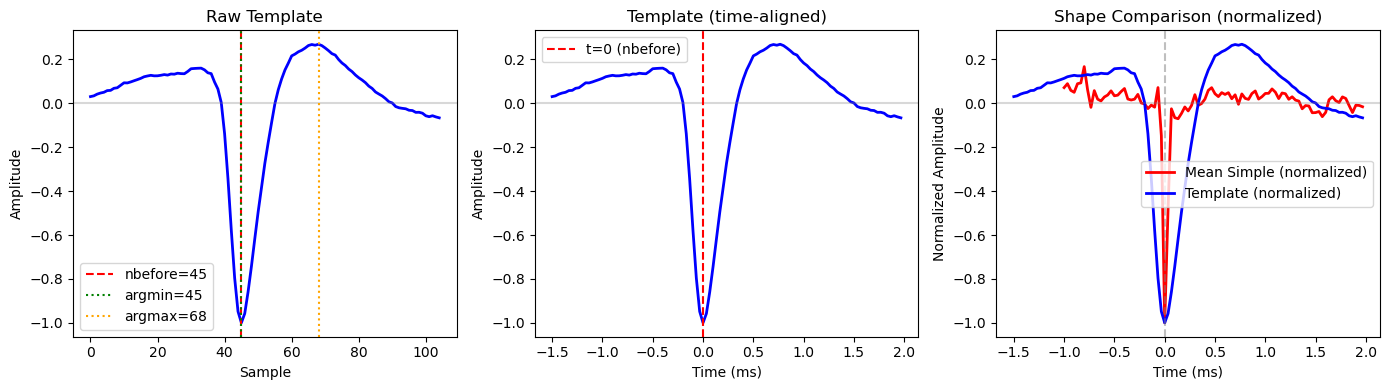


Correlation of mean waveform with template: nan
Correlation of mean waveform with FLIPPED template: nan


In [61]:
# %% Cell: Debug Template Orientation

print("=== TEMPLATE DIAGNOSTIC ===")
print(f"Template min value: {template.min():.3f} at sample {np.argmin(template)}")
print(f"Template max value: {template.max():.3f} at sample {np.argmax(template)}")
print(f"nbefore (peak position): {nbefore}")

# Check if template is oriented correctly for negative spikes
if template.min() < 0 and abs(template.min()) > abs(template.max()):
    print("✓ Template has negative peak (correct for neg spikes)")
else:
    print("⚠️ WARNING: Template may be inverted!")

# Plot template with more detail
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Raw template
ax = axes[0]
ax.plot(template, 'b-', lw=2)
ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax.axvline(nbefore, color='r', linestyle='--', label=f'nbefore={nbefore}')
ax.axvline(np.argmin(template), color='g', linestyle=':', label=f'argmin={np.argmin(template)}')
ax.axvline(np.argmax(template), color='orange', linestyle=':', label=f'argmax={np.argmax(template)}')
ax.set_xlabel('Sample')
ax.set_ylabel('Amplitude')
ax.set_title('Raw Template')
ax.legend()

# Template aligned to time
ax = axes[1]
t_templ = (np.arange(len(template)) - nbefore) / fs * 1000
ax.plot(t_templ, template, 'b-', lw=2)
ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax.axvline(0, color='r', linestyle='--', label='t=0 (nbefore)')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Amplitude')
ax.set_title('Template (time-aligned)')
ax.legend()

# Compare with a typical detected waveform
ax = axes[2]
if len(wf_all_simple) > 0:
    # Normalize both for shape comparison
    mean_simple = np.mean(wf_all_simple, axis=0)
    mean_simple_norm = mean_simple / abs(mean_simple.min())
    template_norm = template / abs(template.min()) if template.min() != 0 else template
    
    ax.plot(t_wf, mean_simple_norm, 'r-', lw=2, label='Mean Simple (normalized)')
    ax.plot(t_templ, template_norm, 'b-', lw=2, label='Template (normalized)')
    ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
    ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Normalized Amplitude')
    ax.set_title('Shape Comparison (normalized)')
    ax.legend()

plt.tight_layout()
plt.show()

# Check correlation between template and mean detected waveform
if len(wf_all_simple) > 0:
    mean_wf = np.mean(wf_all_simple, axis=0)
    
    # Align template to waveform window for correlation
    template_padded = np.zeros(len(mean_wf))
    start_idx = wf_samp_before - nbefore
    end_idx = start_idx + len(template)
    
    if start_idx >= 0 and end_idx <= len(template_padded):
        template_padded[start_idx:end_idx] = template
    
    # Correlation
    corr_normal = np.corrcoef(mean_wf, template_padded)[0, 1]
    corr_flipped = np.corrcoef(mean_wf, -template_padded)[0, 1]
    
    print(f"\nCorrelation of mean waveform with template: {corr_normal:.3f}")
    print(f"Correlation of mean waveform with FLIPPED template: {corr_flipped:.3f}")
    
    if corr_flipped > corr_normal:
        print("\n⚠️ TEMPLATE IS LIKELY INVERTED! The flipped version correlates better.")
        print("   Fix: Use -template or regenerate template with correct polarity")

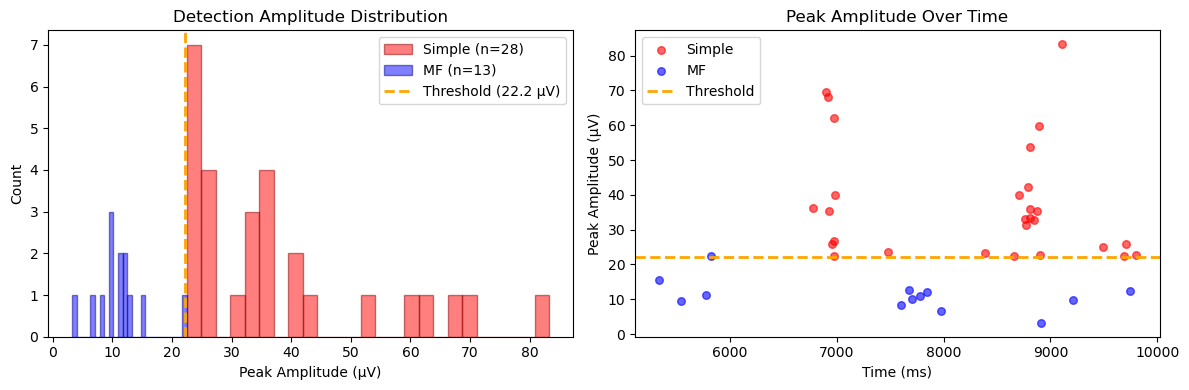

In [62]:
# %% Cell 16: Amplitude Distribution

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel 1: Peak Amplitude Histogram
ax = axes[0]
if len(simple_peak_amp) > 0:
    ax.hist(np.abs(simple_peak_amp), bins=25, alpha=0.5, color='red', 
            label=f'Simple (n={len(simple_peak_amp)})', edgecolor='darkred')
if len(mf_peak_idx) > 0:
    mf_trace_amps = np.abs(trace[mf_peak_idx])
    ax.hist(mf_trace_amps, bins=25, alpha=0.5, color='blue', 
            label=f'MF (n={len(mf_peak_idx)})', edgecolor='darkblue')
ax.axvline(thresh_uV, color='orange', linestyle='--', lw=2, label=f'Threshold ({thresh_uV:.1f} µV)')
ax.set_xlabel('Peak Amplitude (µV)')
ax.set_ylabel('Count')
ax.set_title('Detection Amplitude Distribution')
ax.legend()

# Panel 2: Amplitude vs Time
ax = axes[1]
if len(simple_peak_idx) > 0:
    ax.scatter(t_ms[simple_peak_idx], np.abs(simple_peak_amp), 
               c='red', s=30, alpha=0.6, label='Simple')
if len(mf_peak_idx) > 0:
    ax.scatter(t_ms[mf_peak_idx], np.abs(trace[mf_peak_idx]), 
               c='blue', s=30, alpha=0.6, label='MF')
ax.axhline(thresh_uV, color='orange', linestyle='--', lw=2, label='Threshold')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Peak Amplitude (µV)')
ax.set_title('Peak Amplitude Over Time')
ax.legend()

plt.tight_layout()
plt.savefig('amplitude_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


=== Template Correlation Analysis ===


C:\Users\culle\AppData\Local\Temp\ipykernel_36060\2686175485.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True)
C:\Users\culle\AppData\Local\Temp\ipykernel_36060\2686175485.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax.boxplot(data2, labels=labels2, patch_artist=True)


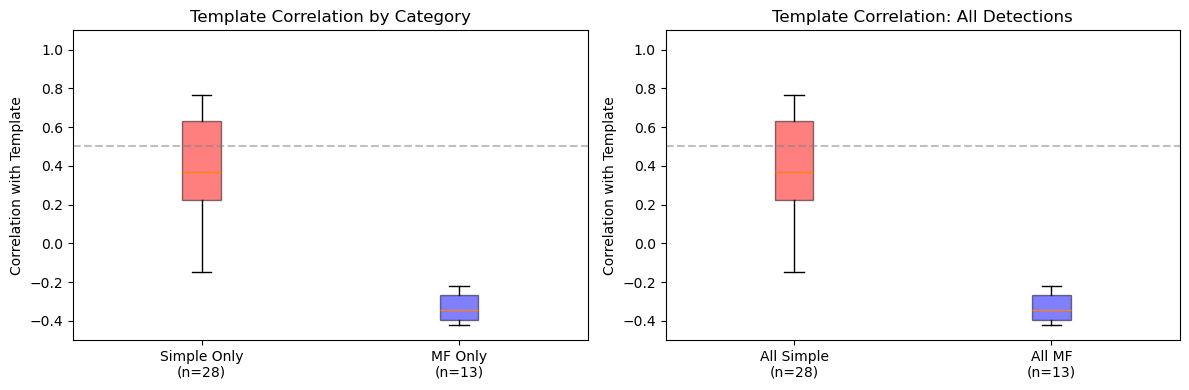


Correlation Statistics:
  All Simple: mean=0.374, median=0.370, std=0.260
  All MF:     mean=-0.336, median=-0.343, std=0.069
  Simple Only: mean=0.374
  MF Only:     mean=-0.336


In [63]:
# %% Cell 17: Template Correlation Analysis

print("\n=== Template Correlation Analysis ===")

def compute_correlation(waveform, template_aligned):
    """Compute normalized correlation between waveform and template."""
    min_len = min(len(waveform), len(template_aligned))
    wf = waveform[:min_len]
    tmpl = template_aligned[:min_len]
    
    wf_norm = (wf - np.mean(wf)) / (np.std(wf) + 1e-10)
    tmpl_norm = (tmpl - np.mean(tmpl)) / (np.std(tmpl) + 1e-10)
    
    return np.corrcoef(wf_norm, tmpl_norm)[0, 1]

# Align template to waveform window
template_aligned = np.zeros(wf_len)
template_start = wf_samp_before - nbefore
template_end = template_start + len(template)
if template_start >= 0 and template_end <= wf_len:
    template_aligned[template_start:template_end] = template
else:
    src_start = max(0, -template_start)
    src_end = min(len(template), wf_len - template_start)
    dst_start = max(0, template_start)
    dst_end = dst_start + (src_end - src_start)
    template_aligned[dst_start:dst_end] = template[src_start:src_end]

# Compute correlations
corr_simple_only = [compute_correlation(wf, template_aligned) for wf in wf_simple_only] if len(wf_simple_only) > 0 else []
corr_mf_only = [compute_correlation(wf, template_aligned) for wf in wf_mf_only] if len(wf_mf_only) > 0 else []
corr_both = [compute_correlation(wf, template_aligned) for wf in wf_both] if len(wf_both) > 0 else []
corr_all_simple = [compute_correlation(wf, template_aligned) for wf in wf_all_simple] if len(wf_all_simple) > 0 else []
corr_all_mf = [compute_correlation(wf, template_aligned) for wf in wf_all_mf] if len(wf_all_mf) > 0 else []

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel 1: By category
ax = axes[0]
data = []
labels = []
colors = []

if len(corr_simple_only) > 0:
    data.append(corr_simple_only)
    labels.append(f'Simple Only\n(n={len(corr_simple_only)})')
    colors.append('red')
if len(corr_mf_only) > 0:
    data.append(corr_mf_only)
    labels.append(f'MF Only\n(n={len(corr_mf_only)})')
    colors.append('blue')
if len(corr_both) > 0:
    data.append(corr_both)
    labels.append(f'Both\n(n={len(corr_both)})')
    colors.append('green')

if data:
    bp = ax.boxplot(data, labels=labels, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.5)

ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_ylabel('Correlation with Template')
ax.set_title('Template Correlation by Category')
ax.set_ylim(-0.5, 1.1)

# Panel 2: All Simple vs All MF
ax = axes[1]
data2 = []
labels2 = []
colors2 = []

if len(corr_all_simple) > 0:
    data2.append(corr_all_simple)
    labels2.append(f'All Simple\n(n={len(corr_all_simple)})')
    colors2.append('red')
if len(corr_all_mf) > 0:
    data2.append(corr_all_mf)
    labels2.append(f'All MF\n(n={len(corr_all_mf)})')
    colors2.append('blue')

if data2:
    bp2 = ax.boxplot(data2, labels=labels2, patch_artist=True)
    for patch, color in zip(bp2['boxes'], colors2):
        patch.set_facecolor(color)
        patch.set_alpha(0.5)

ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_ylabel('Correlation with Template')
ax.set_title('Template Correlation: All Detections')
ax.set_ylim(-0.5, 1.1)

plt.tight_layout()
plt.savefig('correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Print stats
print("\nCorrelation Statistics:")
if len(corr_all_simple) > 0:
    print(f"  All Simple: mean={np.mean(corr_all_simple):.3f}, median={np.median(corr_all_simple):.3f}, std={np.std(corr_all_simple):.3f}")
if len(corr_all_mf) > 0:
    print(f"  All MF:     mean={np.mean(corr_all_mf):.3f}, median={np.median(corr_all_mf):.3f}, std={np.std(corr_all_mf):.3f}")
if len(corr_simple_only) > 0:
    print(f"  Simple Only: mean={np.mean(corr_simple_only):.3f}")
if len(corr_mf_only) > 0:
    print(f"  MF Only:     mean={np.mean(corr_mf_only):.3f}")
if len(corr_both) > 0:
    print(f"  Both:        mean={np.mean(corr_both):.3f}")

In [64]:
# %% Cell 18: Interpretation Summary

print("\n" + "="*60)
print("WAVEFORM ANALYSIS SUMMARY")
print("="*60)
print(f"""
DETECTION COUNTS:
  Simple Threshold: {len(simple_peak_idx)} total detections
  Matched Filter:   {len(mf_peak_idx)} total detections
  Agreement (Both): {len(both)} ({100*len(both)/max(len(simple_peak_idx),1):.1f}% of Simple)
  Simple Only:      {len(simple_only)} (detected by threshold but not MF)
  MF Only:          {len(mf_only)} (detected by MF but not threshold)

INTERPRETATION:
- 'Simple Only' spikes: May be noise OR different waveform shapes not matching template
- 'MF Only' spikes: Template-matching found these despite lower amplitude
- 'Both' spikes: High confidence detections - both methods agree

LOOK AT THE WAVEFORMS:
- If 'Simple Only' waveforms look like real spikes → template may be too specific
- If 'Simple Only' waveforms look like noise → simple threshold is too sensitive
- If 'MF Only' waveforms match template well → MF is finding real small spikes
- If 'MF Only' waveforms are noisy → lower MF threshold or template mismatch

CORRELATION VALUES:
- High correlation (>0.7): Waveform matches template well
- Low correlation (<0.5): Waveform shape differs from template
- If 'Simple Only' has low correlation: These are likely different spike types or noise
- If 'MF Only' has high correlation: These are real spikes that were below amp threshold
""")


WAVEFORM ANALYSIS SUMMARY

DETECTION COUNTS:
  Simple Threshold: 28 total detections
  Matched Filter:   13 total detections
  Agreement (Both): 0 (0.0% of Simple)
  Simple Only:      28 (detected by threshold but not MF)
  MF Only:          13 (detected by MF but not threshold)

INTERPRETATION:
- 'Simple Only' spikes: May be noise OR different waveform shapes not matching template
- 'MF Only' spikes: Template-matching found these despite lower amplitude
- 'Both' spikes: High confidence detections - both methods agree

LOOK AT THE WAVEFORMS:
- If 'Simple Only' waveforms look like real spikes → template may be too specific
- If 'Simple Only' waveforms look like noise → simple threshold is too sensitive
- If 'MF Only' waveforms match template well → MF is finding real small spikes
- If 'MF Only' waveforms are noisy → lower MF threshold or template mismatch

CORRELATION VALUES:
- High correlation (>0.7): Waveform matches template well
- Low correlation (<0.5): Waveform shape differs from